## Goals
In this lab, you will:
- Plot the decision boundary for a logistic regression model. This will give you a better sense of what the model is predicting.


In [1]:
import numpy as np
import matplotlib.pylab as plt

## Dataset

In [2]:
X = np.array([
    [0.5,1.5],
    [1,1],
    [1.5,0.5],
    [3,0.5],
    [2,2],
    [1,2.5]
])

y = np.array([0,0,0,1,1,1]).reshape(-1,1)

print(f"X: {X}")
print(f"y: {y}")

X: [[0.5 1.5]
 [1.  1. ]
 [1.5 0.5]
 [3.  0.5]
 [2.  2. ]
 [1.  2.5]]
y: [[0]
 [0]
 [0]
 [1]
 [1]
 [1]]


## Plot Data

y_flat: [0 0 0 1 1 1]
mask0: [ True  True  True False False False]
mask1: [False False False  True  True  True]


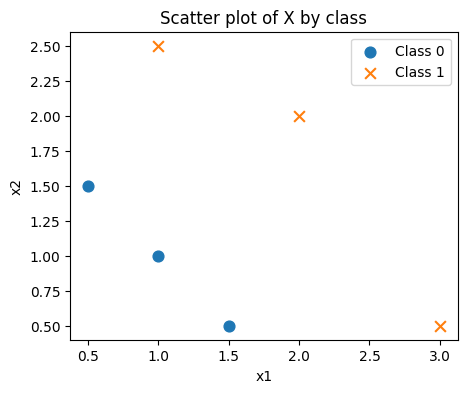

In [21]:
# Create fig, axes you can pass around
fig, ax = plt.subplots(figsize=(5,4))

# Build mask for each class
y_flat = y.ravel()
print(f"y_flat: {y_flat}")

mask_0 = (y_flat == 0)
mask_1 = (y_flat == 1)
print(f"mask0: {mask_0}")
print(f"mask1: {mask_1}")

# Plot on given axes
ax.scatter(X[mask_0, 0], X[mask_0, 1], marker='o', c='tab:blue', label="Class 0", s=60)
ax.scatter(X[mask_1, 0], X[mask_1, 1], marker='x', c='tab:orange', label="Class 1", s=60)

# Cosmetics
ax.set_title('Scatter plot of X by class')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()


plt.show()


## Sigmoid Function

In [37]:
def sigmoid(z):

    return 1/(1+np.exp(-z))

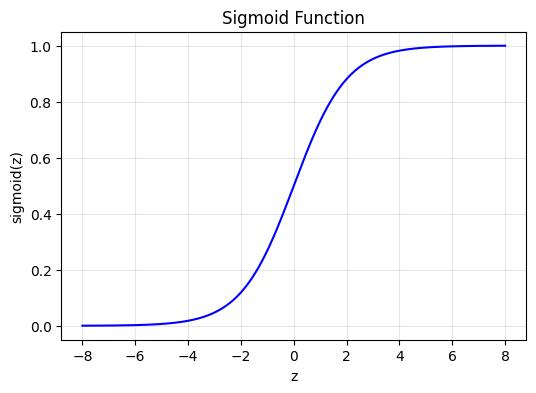

In [38]:

z_grid = np.linspace(-8, 8, 400)
yp_grid = sigmoid(z_grid)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(z_grid, yp_grid, c='b')
ax.set_title("Sigmoid Function")
ax.set_xlabel("z")
ax.set_ylabel("sigmoid(z)")
ax.grid(True, alpha=0.3)
plt.show()


## Logistic regression model


* Suppose you'd like to train a logistic regression model on this data which has the form   

  $f(x) = g(w_0x_0+w_1x_1 + b)$
  
  where $g(z) = \frac{1}{1+e^{-z}}$, which is the sigmoid function


* Let's say that you trained the model and get the parameters as $b = -3, w_0 = 1, w_1 = 1$. That is,

  $f(x) = g(x_0+x_1-3)$

  (You'll learn how to fit these parameters to the data further in the course)
  
  
Let's try to understand what this trained model is predicting by plotting its decision boundary

In [26]:
w = np.array([1,1])
b = -3

z = np.dot(X,w) + b
yp = sigmoid(z)
print(z)
print(yp)

[-1.  -1.  -1.   0.5  1.   0.5]
[0.26894142 0.26894142 0.26894142 0.62245933 0.73105858 0.62245933]


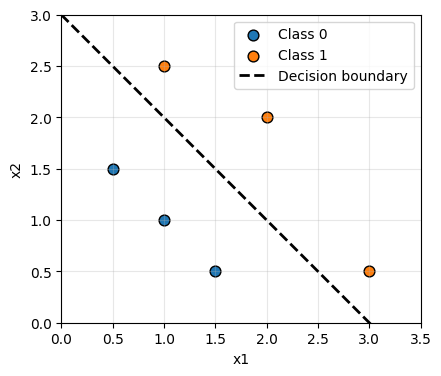

In [36]:

# Plot data
fig, ax = plt.subplots(figsize=(6, 4))
mask0 = (y.ravel() == 0)
mask1 = (y.ravel() == 1)
ax.scatter(X[mask0, 0], X[mask0, 1], c='tab:blue', label='Class 0', s=60, edgecolor='k')
ax.scatter(X[mask1, 0], X[mask1, 1], c='tab:orange', label='Class 1', s=60, edgecolor='k')

# Decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1/w2)*x1 - b/w2
x1_min, x1_max = 0.0, 3.5
x1_line = np.linspace(x1_min, x1_max, 200)
x2_line = -(w[0] / w[1]) * x1_line - b / w[1]
ax.plot(x1_line, x2_line, 'k--', lw=2, label='Decision boundary')

# Optional: color the two half-spaces (to see which side is class 1)
# Evaluate score on the line x2 = value to determine side; or use a grid (see Method 2)

ax.set_xlim(0, 3.5)
ax.set_ylim(0, 3.0)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
